<a href="https://colab.research.google.com/github/lbnartey1/Loan-Approval-Prediction/blob/main/Task_4_Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Task** 4: Loan Approval Prediction

In [3]:
!pip install -q imbalanced-learn xgboost

import os, warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Pre-processing
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute          import SimpleImputer

# ── Models
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier, plot_tree
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

# ── Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# ── Class imbalance
from imblearn.over_sampling  import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline       import Pipeline as ImbPipeline

print("All imports successful!")

All imports successful!


In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
DATA_DIR = "/content/drive/MyDrive/Elevvo Internship./Task 4 - Loan Approval/loan_approval_dataset.csv"

df = pd.read_csv(DATA_DIR)
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
print(f"Dataset loaded!")
print(f"Shape:({df.shape[0]} rows, {df.shape[1]} columns)")
print()
df.head(10)

Dataset loaded!
Shape:(4269 rows, 13 columns)



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [6]:
print("Column data types:")
print(df.dtypes)
print()
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
print("Summary statistics:")
display(df.describe(include='all').round(2))

Column data types:
loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

Summary statistics:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.0,4269.0,4269,4269,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.0,2.5,NaN,NaN,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43,NaN
std,1232.5,1.7,NaN,NaN,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31,NaN
min,1.0,0.0,NaN,NaN,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00,NaN
25%,1068.0,1.0,NaN,NaN,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00,NaN
50%,2135.0,3.0,NaN,NaN,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00,NaN
75%,3202.0,4.0,NaN,NaN,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00,NaN


In [7]:
# ── Class distribution — the first thing to check in classification ───────────
print("Target variable (Loan_Status) distribution:")
counts = df[' loan_status'].value_counts()
pcts   = df[' loan_status'].value_counts(normalize=True) * 100
for cls, cnt, pct in zip(counts.index, counts.values, pcts.values):
    label = "Approved" if cls == 'Y' else "Rejected"
    bar   = "█" * int(pct / 2)
    print(f"   {cls} ({label}): {cnt:>4}  ({pct:.1f}%)  {bar}")

print()
if pcts.min() < 30:
    print("⚠️  Class imbalance detected!")
    print("   The minority class has fewer samples, which can bias the model.")
    print("   We will apply SMOTE later to fix this.")
else:
    print("✅ Classes are reasonably balanced.")

Target variable (Loan_Status) distribution:
   Approved (Rejected): 2656  (62.2%)  ███████████████████████████████
   Rejected (Rejected): 1613  (37.8%)  ██████████████████

✅ Classes are reasonably balanced.


Exploratory Data Analysis

🔍 Missing value counts:
Series([], )

Total cells with missing data: 0


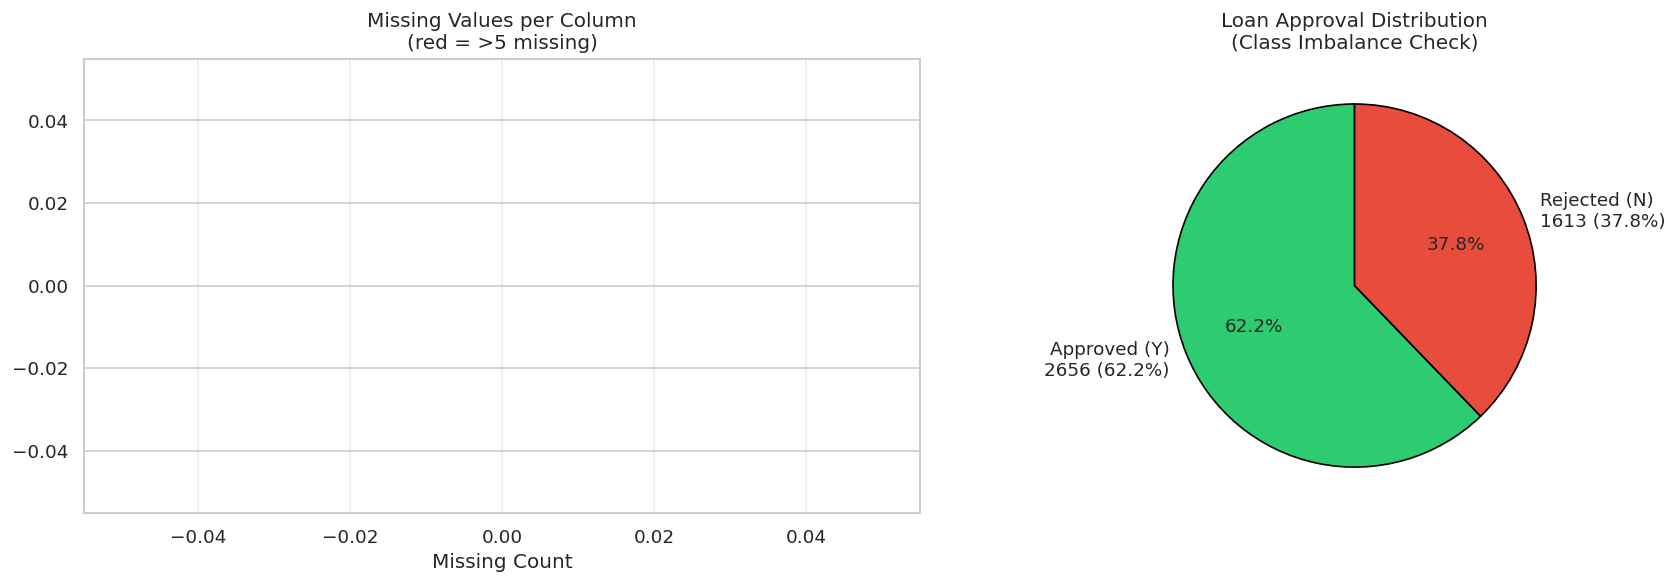

In [8]:
# ── Missing values heatmap ───────────────────────────────────────────────────
print("🔍 Missing value counts:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.to_string())
print(f"\nTotal cells with missing data: {df.isnull().sum().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Missing bar chart
# The 'missing' Series is empty, so this block will execute without issues but won't plot anything.
# No changes needed here, as the previous output correctly indicated 0 missing values.
colors_miss = ['#E74C3C' if v > 5 else '#F39C12' for v in missing.values]
axes[0].barh(missing.index[::-1], missing.values[::-1],
             color=colors_miss[::-1], edgecolor='black')
axes[0].set_xlabel("Missing Count")
axes[0].set_title("Missing Values per Column\n(red = >5 missing)", fontsize=12)
for i, v in enumerate(missing.values[::-1]):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=10)
axes[0].grid(axis='x', alpha=0.4)

# Class distribution pie
# Correctly count 'Approved' and 'Rejected' values from the ' loan_status' column after stripping whitespace
df[' loan_status'] = df[' loan_status'].str.strip() # Strip whitespace from the column
approved = (df[' loan_status'] == 'Approved').sum()
rejected = (df[' loan_status'] == 'Rejected').sum()
axes[1].pie([approved, rejected],
            labels=[f'Approved (Y)\n{approved} ({approved/len(df)*100:.1f}%)',
                    f'Rejected (N)\n{rejected} ({rejected/len(df)*100:.1f}%)'],
            colors=['#2ECC71','#E74C3C'], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='black'))
axes[1].set_title("Loan Approval Distribution\n(Class Imbalance Check)", fontsize=12)

plt.tight_layout()
plt.show()

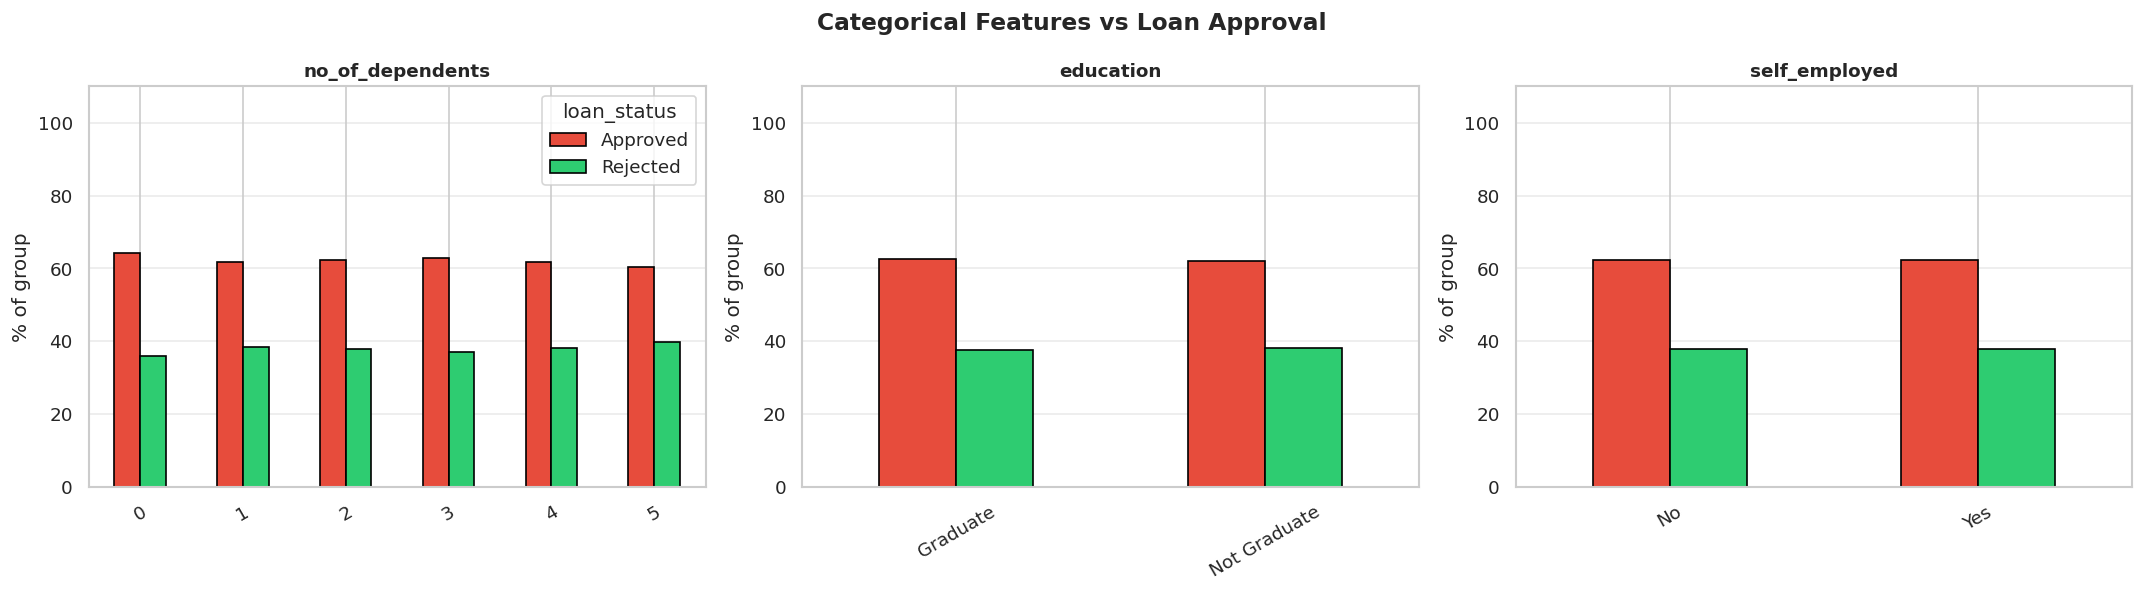

✅ Saved → Google Drive: loan_eda_categorical.png


In [9]:
# ── Categorical features vs Loan Status ──────────────────────────────────────

# Strip whitespace from all column names for consistent access
df.columns = df.columns.str.strip()

# Update categorical columns based on the actual DataFrame columns
cat_cols = ['no_of_dependents', 'education', 'self_employed']

# Adjust subplot layout for the new number of categorical features
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5)) # Changed to 1 row, len(cat_cols) columns
fig.suptitle("Categorical Features vs Loan Approval", fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    # Ensure the target column name is also correct (loan_status, not Loan_Status)
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#E74C3C','#2ECC71'], edgecolor='black',
            rot=30, legend=(col == cat_cols[0]))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(""); ax.set_ylabel("% of group")
    ax.grid(axis='y', alpha=0.4)
    ax.set_ylim(0, 110)

# No need to hide extra subplots if layout is adjusted correctly

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/loan_eda_categorical.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: loan_eda_categorical.png")

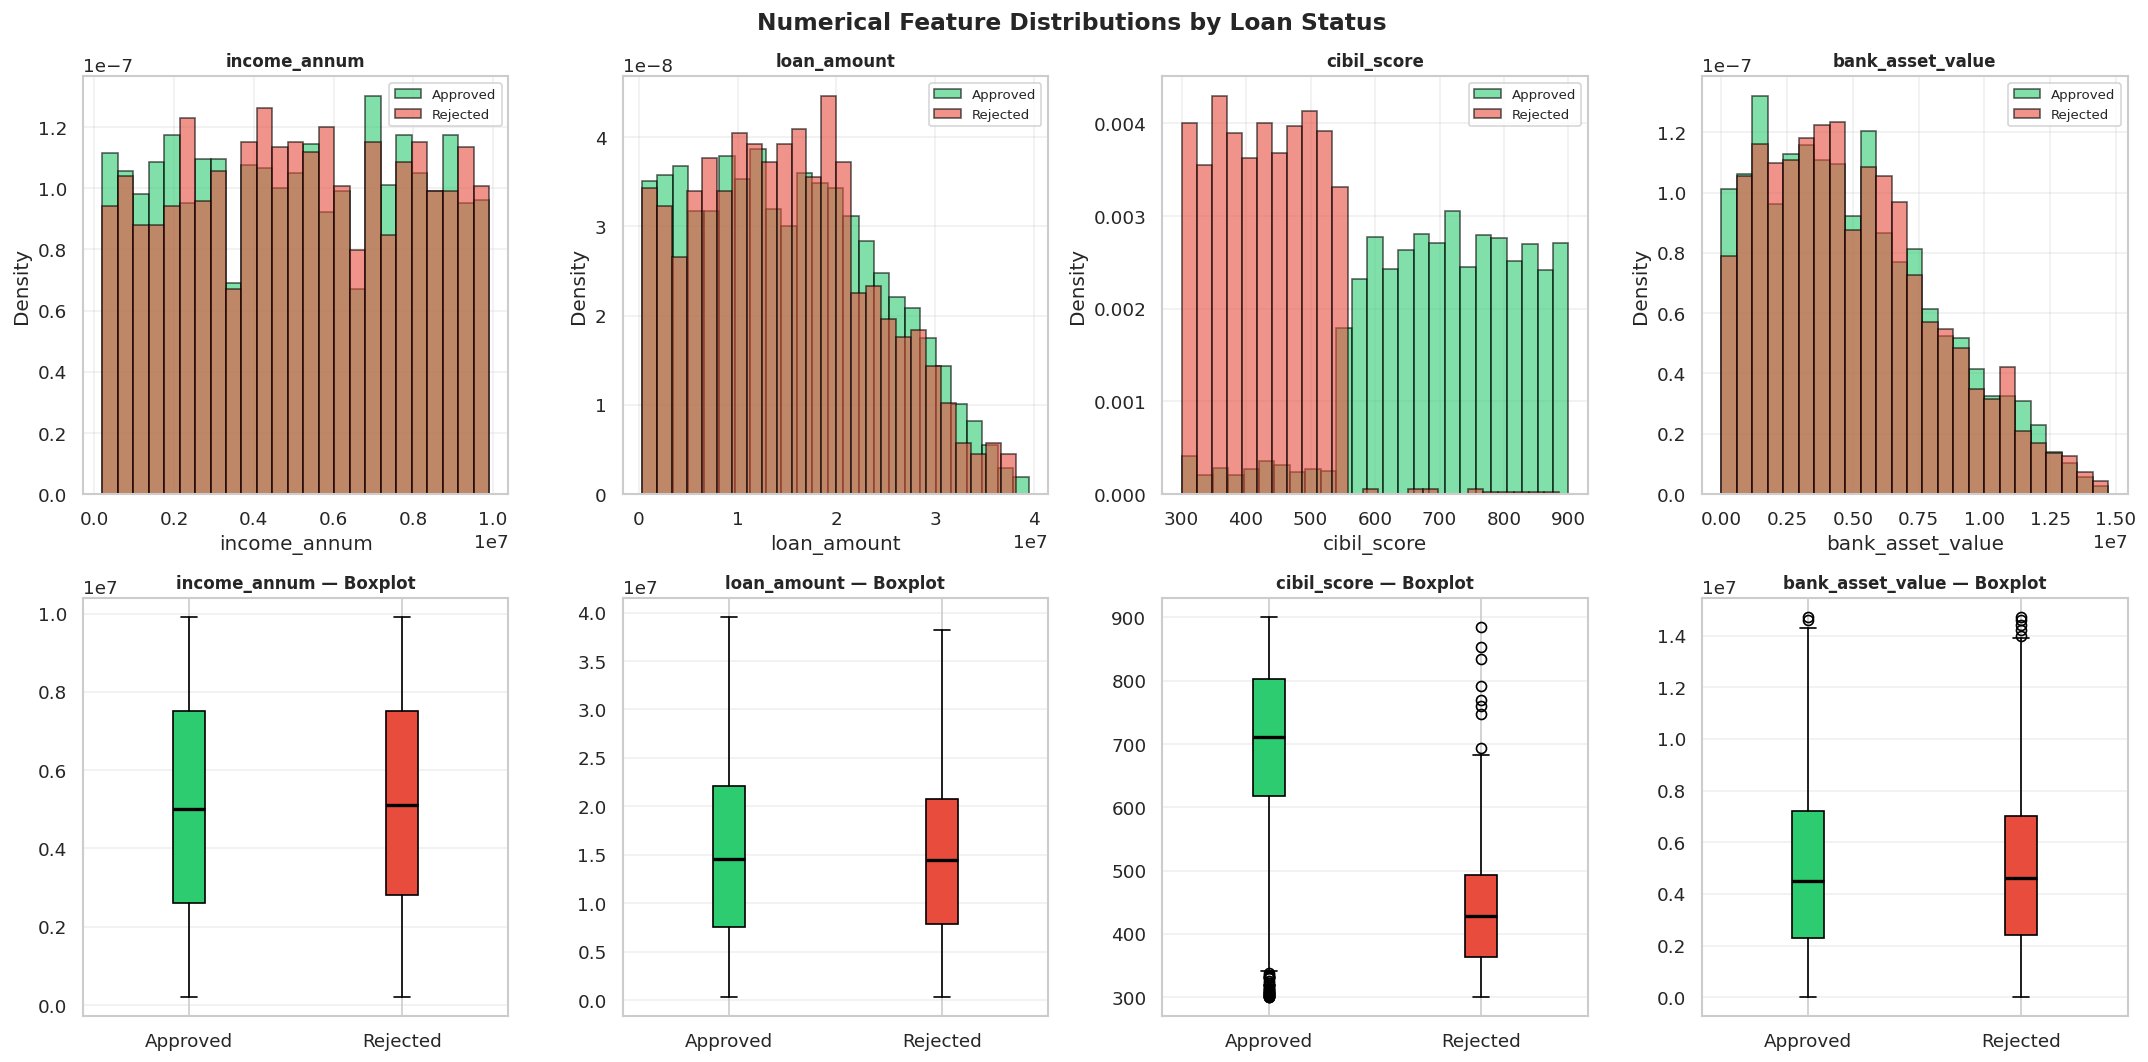

✅ Saved → Google Drive: loan_eda_numerical.png


In [10]:
# ── Numerical features distribution by Loan Status ───────────────────────────
# Update num_cols with actual numerical column names from the DataFrame
num_cols = ['income_annum','loan_amount','cibil_score','bank_asset_value']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Numerical Feature Distributions by Loan Status",
             fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    # Distribution plot
    ax = axes[0, i]
    for status, color, label in [('Approved','#2ECC71','Approved'), ('Rejected','#E74C3C','Rejected')]:
        # Use 'loan_status' (after stripping whitespace in previous cell) as the target column
        data = df[df['loan_status']==status][col].dropna()
        ax.hist(data, bins=25, color=color, alpha=0.6, edgecolor='black',
                label=label, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel("Density")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Box plot
    ax2 = axes[1, i]
    data_app = [df[df['loan_status']=='Approved'][col].dropna().values,
                df[df['loan_status']=='Rejected'][col].dropna().values]
    bp = ax2.boxplot(data_app, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ECC71')
    bp['boxes'][1].set_facecolor('#E74C3C')
    ax2.set_xticklabels(['Approved','Rejected'])
    ax2.set_title(f"{col} — Boxplot", fontsize=10, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/loan_eda_numerical.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: loan_eda_numerical.png")

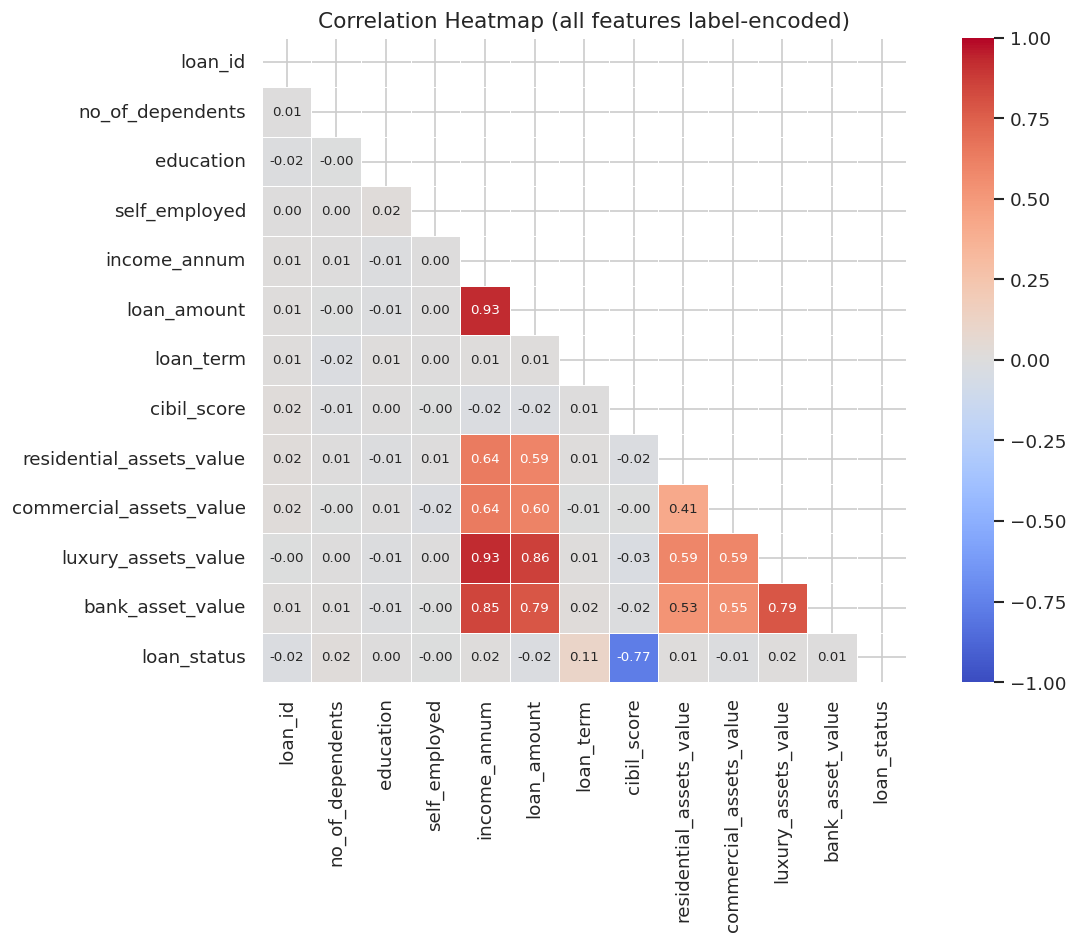

✅ Saved → Google Drive: loan_correlation.png


In [11]:
# ── Correlation heatmap (after encoding) ──────────────────────────────────────
df_corr = df.copy()
for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(11, 8))
corr = df_corr.drop('Loan_ID', axis=1, errors='ignore').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap (all features label-encoded)", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/loan_correlation.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: loan_correlation.png")

Data Preprocessing

In [12]:
def preprocess(df, is_train=True):
    """
    Full preprocessing pipeline:
    - Drop ID column
    - Separate target (train only)
    - Impute missing values (though current df has none)
    - Feature engineering (based on available columns)
    - Encode categoricals
    Returns X (features), y (target or None), feature_names
    """
    df = df.copy()

    # Ensure all column names are stripped of whitespace for consistent access
    df.columns = df.columns.str.strip()

    # Drop ID — useless for prediction
    df.drop(columns=['loan_id'], errors='ignore', inplace=True)

    # Separate target before imputation/feature engineering on X
    y = None
    if is_train and 'loan_status' in df.columns:
        # Map 'Approved' to 1, 'Rejected' to 0
        y = (df['loan_status'] == 'Approved').astype(int)
        df.drop(columns=['loan_status'], inplace=True)

    # ── Impute missing values (Check for missing values, though EDA shows none) ──────────────────────────
    # Re-identify categorical and numerical columns after dropping loan_id and loan_status
    current_cat_cols = df.select_dtypes('object').columns.tolist()
    current_num_cols = df.select_dtypes(['int64','float64']).columns.tolist()

    # Categorical: fill with mode (most common value)
    for col in current_cat_cols:
        if df[col].isnull().any(): # Check if there are actual NaNs
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"   Filled {col:<25} with mode: '{mode_val}'")

    # Numerical: fill with median
    for col in current_num_cols:
        if df[col].isnull().any(): # Check if there are actual NaNs
            med_val = df[col].median()
            df[col].fillna(med_val, inplace=True)
            print(f"   Filled {col:<25} with median: {med_val:.1f}")

    # ── Feature engineering ───────────────────────────────────────────────────
    # Create new features based on the columns available in the current dataset
    df['IncomePerLoanAmount'] = df['income_annum'] / (df['loan_amount'] + 1e-6) # Add small epsilon to avoid div by zero
    df['TotalAssets'] = df['residential_assets_value'] + df['commercial_assets_value'] + df['luxury_assets_value'] + df['bank_asset_value']
    df['AssetsToIncomeRatio'] = df['TotalAssets'] / (df['income_annum'] + 1e-6)
    df['LoanAmountPerTerm'] = df['loan_amount'] / (df['loan_term'] + 1e-6)

    # Log-transform potentially skewed numerical columns
    # Exclude 'residential_assets_value' as it was skipped for the full dataset
    log_transform_cols = ['income_annum', 'loan_amount',
                          'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
                          'TotalAssets', 'IncomePerLoanAmount', 'AssetsToIncomeRatio', 'LoanAmountPerTerm']
    for col in log_transform_cols:
        if col in df.columns:
            # Check if values are non-negative before log transformation
            if (df[col] >= 0).all():
                df[f'Log_{col}'] = np.log1p(df[col])
            else:
                print(f"   Skipping log transformation for '{col}' due to negative values.")

    # ── Encode categoricals ───────────────────────────────────────────────────
    # 'education' and 'self_employed' are the object type columns remaining
    binary_map = {
        'education': {'Graduate': 1, 'Not Graduate': 0},
        'self_employed': {'Yes': 1, 'No': 0},
    }
    for col, mapping in binary_map.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)
            print(f"   Label encoded '{col}'")

    feature_names = df.columns.tolist()
    return df.values.astype(float), y.values if y is not None else None, feature_names

print("Running preprocessing...")
X, y, FEATURE_NAMES = preprocess(df, is_train=True)

print(f"\n✅ Preprocessing complete!")
print(f"   Features : {X.shape[1]}")
print(f"   Samples  : {X.shape[0]}")
print(f"   Approved (1): {y.sum()}  ({y.mean()*100:.1f}%)")
print(f"   Rejected (0): {(1-y).sum()}  ({(1-y).mean()*100:.1f}%)")
print(f"\nFinal feature list:")
for i, f in enumerate(FEATURE_NAMES):
    print(f"   {i+1:>2}. {f}")

Running preprocessing...
   Label encoded 'education'
   Label encoded 'self_employed'

✅ Preprocessing complete!
   Features : 24
   Samples  : 4269
   Approved (1): 2656  (62.2%)
   Rejected (0): 1613  (37.8%)

Final feature list:
    1. no_of_dependents
    2. education
    3. self_employed
    4. income_annum
    5. loan_amount
    6. loan_term
    7. cibil_score
    8. residential_assets_value
    9. commercial_assets_value
   10. luxury_assets_value
   11. bank_asset_value
   12. IncomePerLoanAmount
   13. TotalAssets
   14. AssetsToIncomeRatio
   15. LoanAmountPerTerm
   16. Log_income_annum
   17. Log_loan_amount
   18. Log_commercial_assets_value
   19. Log_luxury_assets_value
   20. Log_bank_asset_value
   21. Log_TotalAssets
   22. Log_IncomePerLoanAmount
   23. Log_AssetsToIncomeRatio
   24. Log_LoanAmountPerTerm


Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # ← preserves class ratio in both splits
)

# Scale features (important for Logistic Regression)
scaler   = StandardScaler()
Xtr_sc   = scaler.fit_transform(X_train)
Xte_sc   = scaler.transform(X_test)

print("✅ Train/test split complete (stratified)")
print(f"   Train: {X_train.shape}  →  Approved: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Test : {X_test.shape}   →  Approved: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

✅ Train/test split complete (stratified)
   Train: (3415, 24)  →  Approved: 2125 (62.2%)
   Test : (854, 24)   →  Approved: 531 (62.2%)


Evaluation Metrics

In [14]:
RESULTS = {}   # Will store all model results for final comparison

def full_evaluate(name, y_true, y_pred, y_proba=None, store=True):
    """Prints and stores all key metrics for a classifier."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba) if y_proba is not None else float('nan')

    print(f"  {'Model':<30}: Acc={acc:.4f}  Prec={prec:.4f}  "
          f"Rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

    if store:
        RESULTS[name] = {
            'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1': f1, 'AUC': auc,
            'y_pred': y_pred, 'y_proba': y_proba
        }
    return acc, prec, rec, f1, auc

def plot_confusion(name, y_true, y_pred, ax):
    """Plots a styled confusion matrix on the given axis."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected','Approved'],
                yticklabels=['Rejected','Approved'],
                linewidths=0.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix\n{name}", fontsize=10, fontweight='bold')

print("✅ Evaluation helper ready!")

✅ Evaluation helper ready!


Logistic Regression

In [15]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Handles imbalance automatically
    random_state=42,
    C=1.0                     # Regularisation strength (lower C = stronger regularisation)
)
lr.fit(Xtr_sc, y_train)
lr_pred  = lr.predict(Xte_sc)
lr_proba = lr.predict_proba(Xte_sc)[:, 1]

print("Logistic Regression results:")
full_evaluate("Logistic Regression", y_test, lr_pred, lr_proba)

print()
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Rejected (N)', 'Approved (Y)']))

Logistic Regression results:
  Model                         : Acc=0.9333  Prec=0.9593  Rec=0.9322  F1=0.9456  AUC=0.9798

Classification Report:
              precision    recall  f1-score   support

Rejected (N)       0.89      0.93      0.91       323
Approved (Y)       0.96      0.93      0.95       531

    accuracy                           0.93       854
   macro avg       0.93      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854



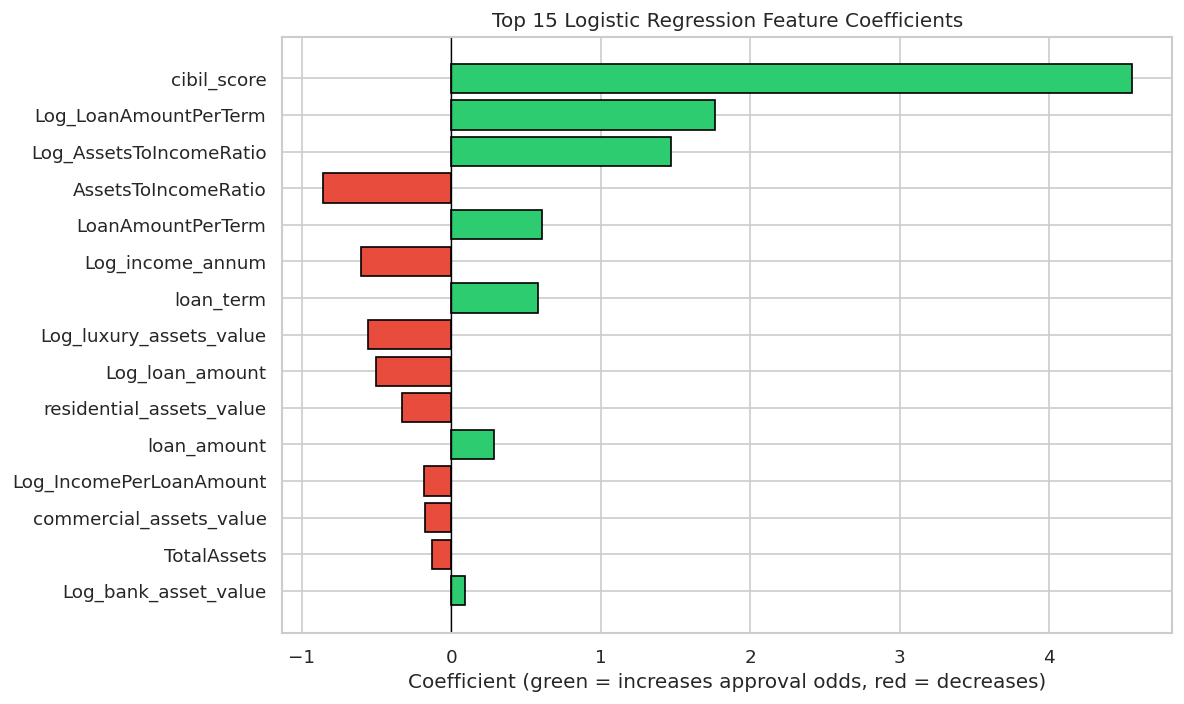

✅ Saved → Google Drive: lr_coefficients.png


In [16]:
# ── Feature coefficients ──────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#2ECC71' if c > 0 else '#E74C3C' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
         color=colors[::-1], edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Coefficient (green = increases approval odds, red = decreases)")
plt.title("Top 15 Logistic Regression Feature Coefficients", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lr_coefficients.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: lr_coefficients.png")

Decision tree classifier

In [17]:
dt = DecisionTreeClassifier(
    max_depth=6,              # Limit tree depth to avoid overfitting
    min_samples_split=10,     # Need at least 10 samples to split a node
    min_samples_leaf=5,       # Leaf nodes need at least 5 samples
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print("Decision Tree results:")
full_evaluate("Decision Tree", y_test, dt_pred, dt_proba)
print()
print("Classification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Rejected (N)', 'Approved (Y)']))

Decision Tree results:
  Model                         : Acc=0.9988  Prec=0.9981  Rec=1.0000  F1=0.9991  AUC=0.9985

Classification Report:
              precision    recall  f1-score   support

Rejected (N)       1.00      1.00      1.00       323
Approved (Y)       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



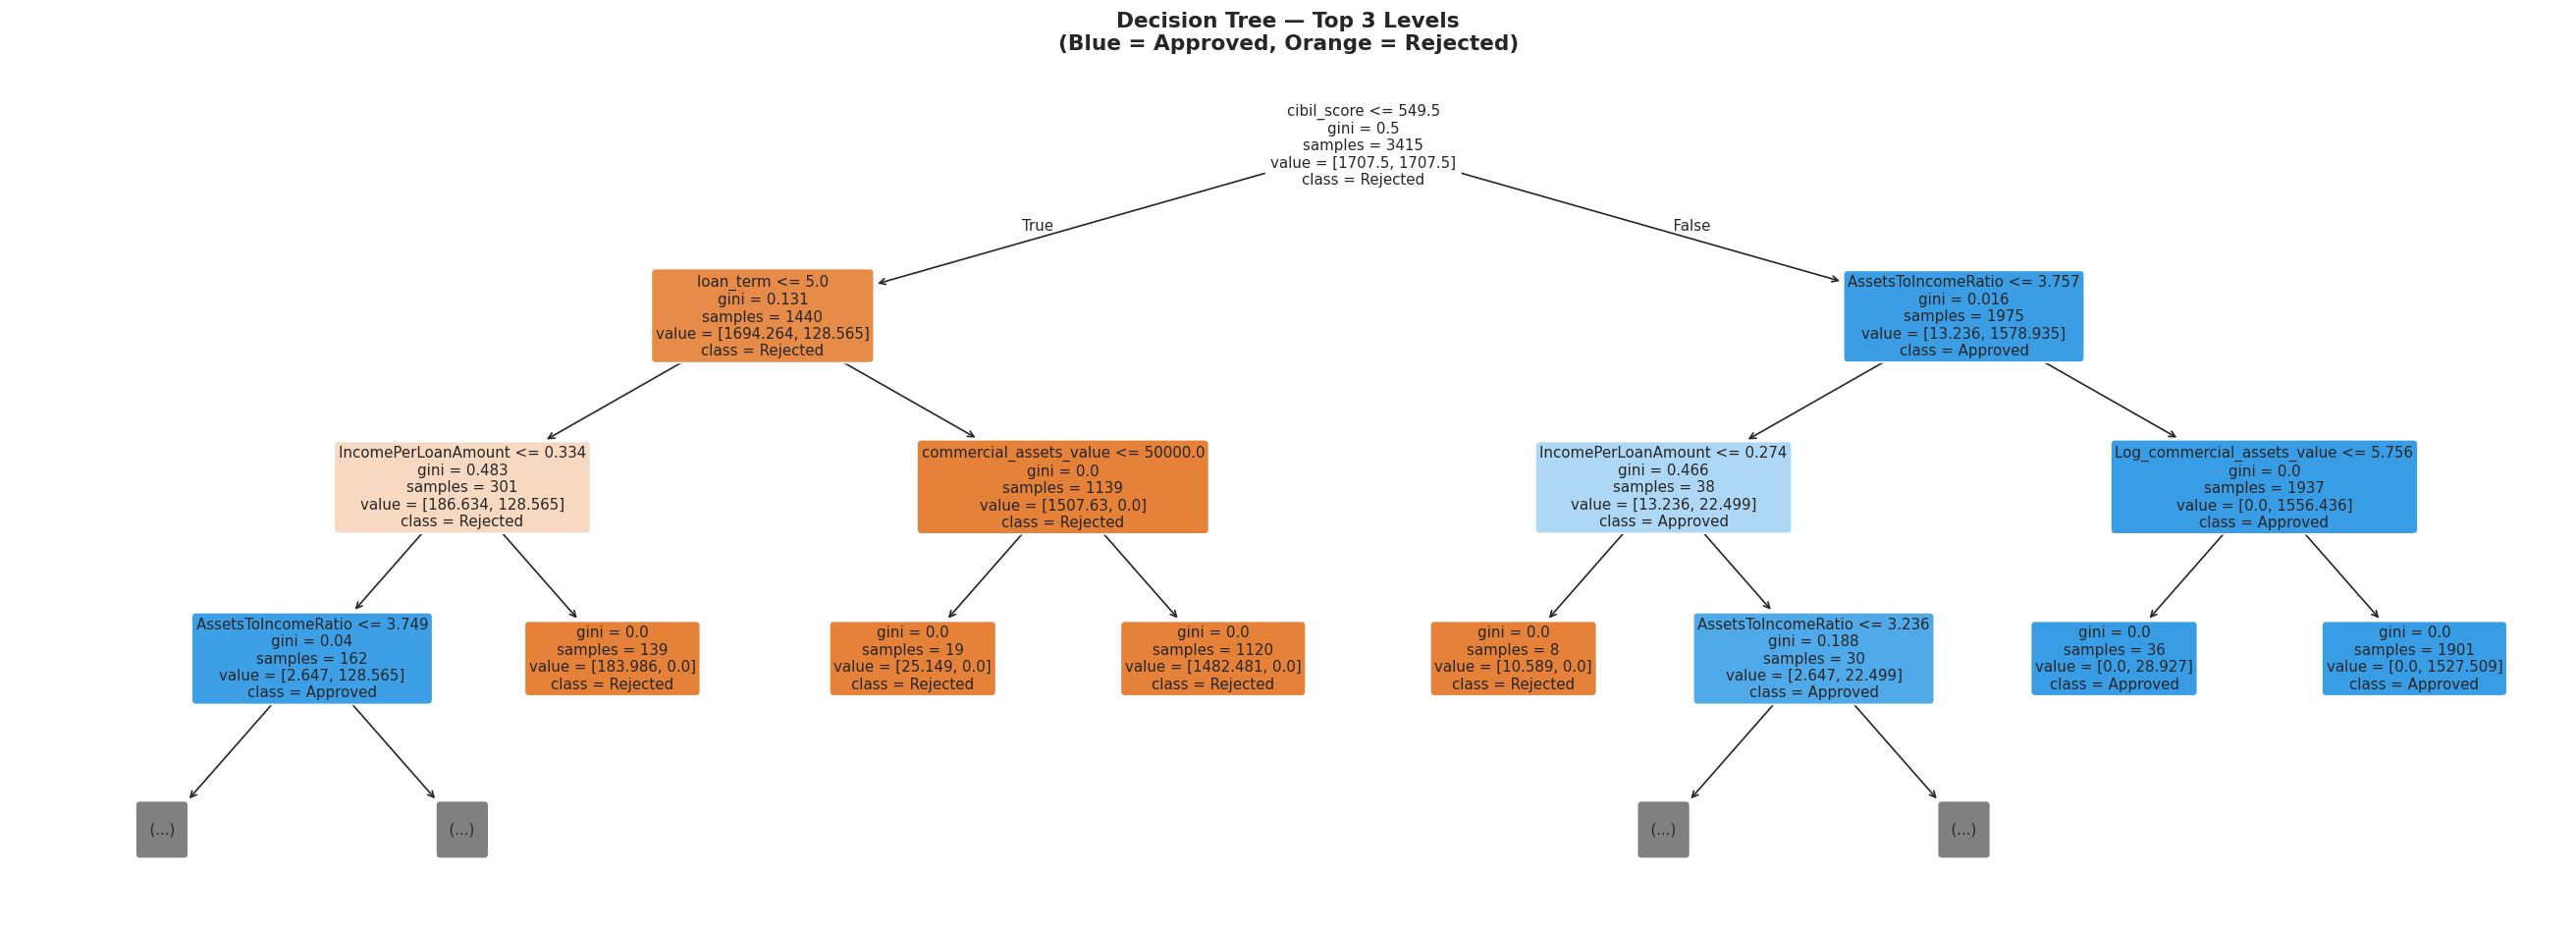

✅ Saved → Google Drive: decision_tree_viz.png


In [18]:
# Visualise the top 3 levels of the decision tree (full tree is too large to read)
plt.figure(figsize=(22, 8))
plot_tree(
    dt, max_depth=3,
    feature_names=FEATURE_NAMES,
    class_names=['Rejected','Approved'],
    filled=True, rounded=True,
    fontsize=9
)
plt.title("Decision Tree — Top 3 Levels\n(Blue = Approved, Orange = Rejected)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/decision_tree_viz.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → Google Drive: decision_tree_viz.png")

Confusion Matrices - Logistic Regression vs Decision Tree.

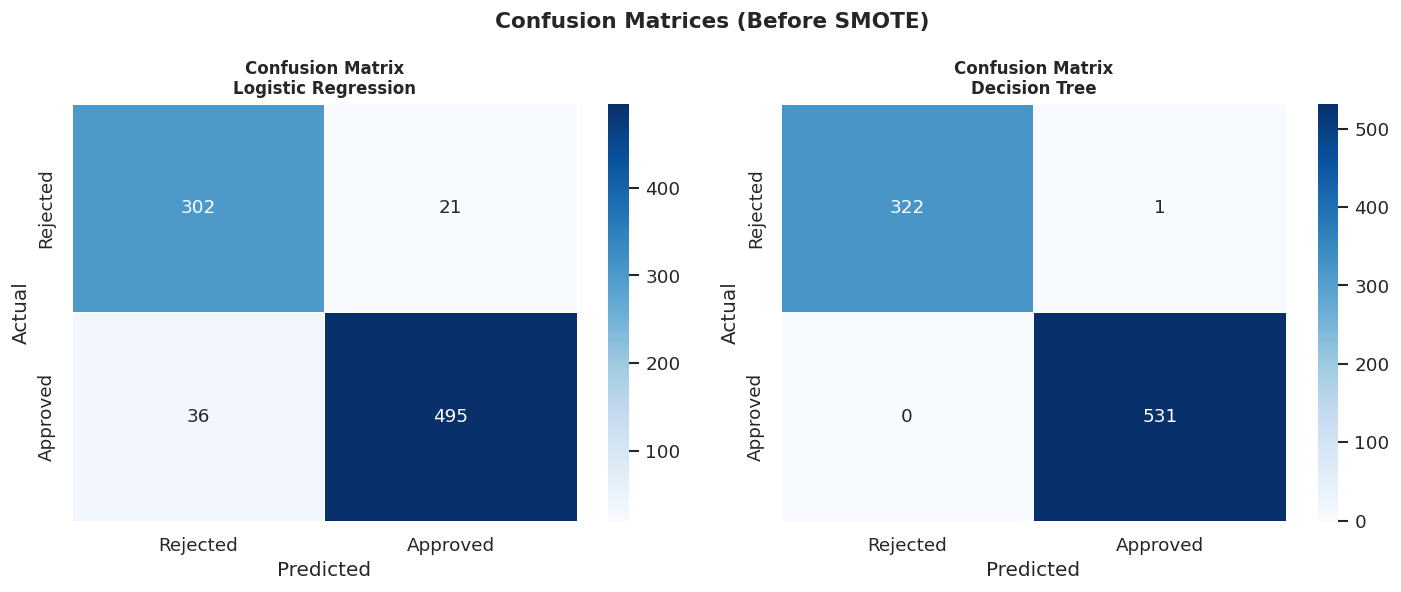

✅ Saved → Google Drive: confusion_before_smote.png

Reading the confusion matrix:
  Top-left  (TN): Correctly predicted 'Rejected'
  Top-right (FP): Predicted 'Approved' but actually 'Rejected' ← costly mistake for lenders!
  Bot-left  (FN): Predicted 'Rejected' but actually 'Approved' ← lost business
  Bot-right (TP): Correctly predicted 'Approved'


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices (Before SMOTE)", fontsize=13, fontweight='bold')

plot_confusion("Logistic Regression", y_test, lr_pred, axes[0])
plot_confusion("Decision Tree",       y_test, dt_pred, axes[1])

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_before_smote.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: confusion_before_smote.png")
print()
print("Reading the confusion matrix:")
print("  Top-left  (TN): Correctly predicted 'Rejected'")
print("  Top-right (FP): Predicted 'Approved' but actually 'Rejected' ← costly mistake for lenders!")
print("  Bot-left  (FN): Predicted 'Rejected' but actually 'Approved' ← lost business")
print("  Bot-right (TP): Correctly predicted 'Approved'")

ROC Curves

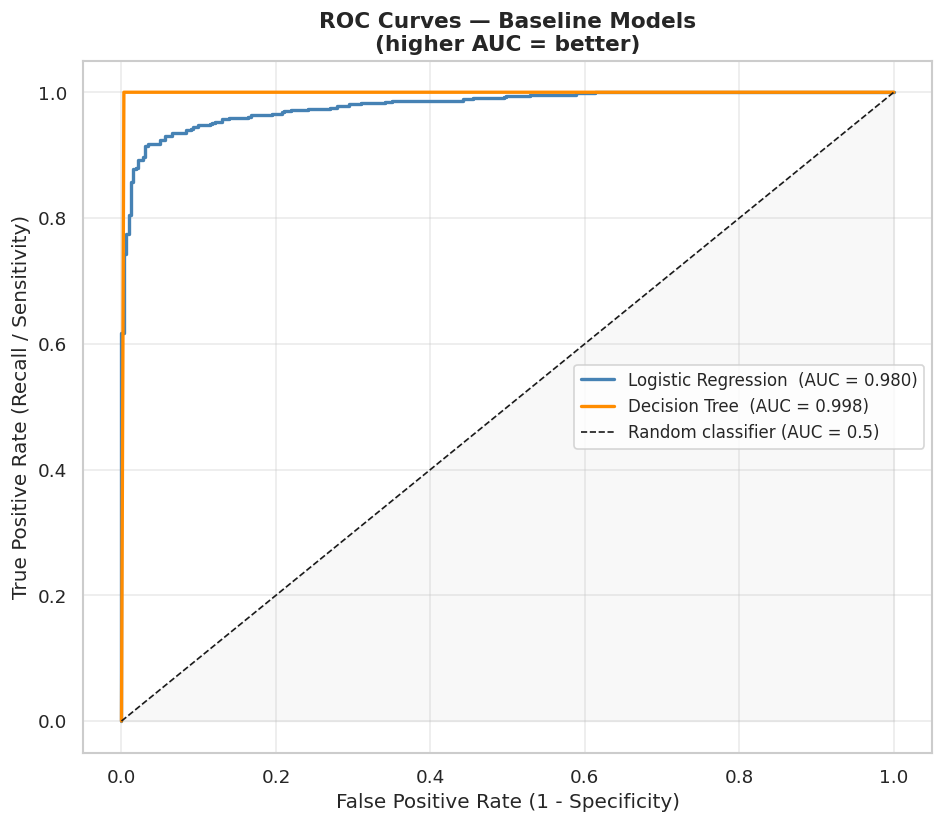

✅ Saved → Google Drive: roc_before_smote.png


In [20]:
plt.figure(figsize=(8, 7))
for name, color in [("Logistic Regression", "steelblue"), ("Decision Tree", "darkorange")]:
    fpr, tpr, _ = roc_curve(y_test, RESULTS[name]['y_proba'])
    auc          = RESULTS[name]['AUC']
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {auc:.3f})")

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
plt.fill_between([0,1],[0,1], alpha=0.05, color='grey')
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
plt.title("ROC Curves — Baseline Models\n(higher AUC = better)", fontsize=13, fontweight='bold')
plt.legend(fontsize=10); plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/roc_before_smote.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: roc_before_smote.png")

Bonus: SMOTE - Fixing Class Imbalance

Class distribution BEFORE SMOTE:
   Class 0 (Rejected): 1290  (37.8%)
   Class 1 (Approved): 2125  (62.2%)

Class distribution AFTER SMOTE:
   Class 0 (Rejected): 2125  (50.0%)
   Class 1 (Approved): 2125  (50.0%)

   Samples added: 835


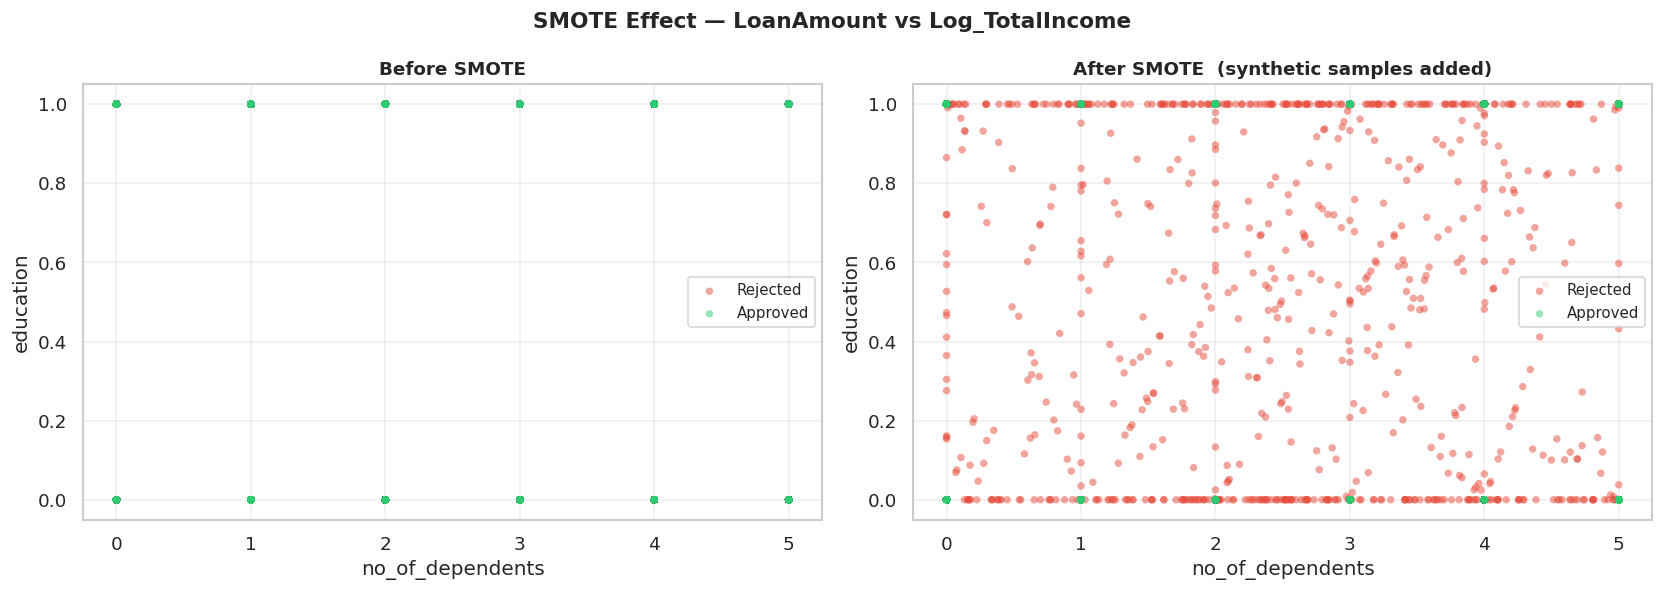

✅ Saved → Google Drive: smote_effect.png


In [21]:
print("Class distribution BEFORE SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Class {u} ({'Approved' if u==1 else 'Rejected'}): {c}  ({c/len(y_train)*100:.1f}%)")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Class {u} ({'Approved' if u==1 else 'Rejected'}): {c}  ({c/len(y_train_sm)*100:.1f}%)")

print(f"\n   Samples added: {len(X_train_sm) - len(X_train)}")

# Scale the SMOTE-balanced training data
Xtr_sm_sc = scaler.fit_transform(X_train_sm)   # Refit scaler on SMOTE data
Xte_sm_sc = scaler.transform(X_test)

# ── Visualise SMOTE effect on 2 key features ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SMOTE Effect — LoanAmount vs Log_TotalIncome",
             fontsize=13, fontweight='bold')

feat_a = FEATURE_NAMES.index('LoanAmount') if 'LoanAmount' in FEATURE_NAMES else 0
feat_b = FEATURE_NAMES.index('Log_TotalIncome') if 'Log_TotalIncome' in FEATURE_NAMES else 1

for ax, (X_plot, y_plot, title) in zip(axes, [
    (X_train,    y_train,    "Before SMOTE"),
    (X_train_sm, y_train_sm, "After SMOTE  (synthetic samples added)")
]):
    for cls, color, label in [(0,'#E74C3C','Rejected'), (1,'#2ECC71','Approved')]:
        mask = y_plot == cls
        ax.scatter(X_plot[mask, feat_a], X_plot[mask, feat_b],
                   c=color, s=20, alpha=0.5, label=label, edgecolors='none')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(FEATURE_NAMES[feat_a]); ax.set_ylabel(FEATURE_NAMES[feat_b])
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/smote_effect.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: smote_effect.png")

Bonus: Re-train Baseline Models on SMOTE.

In [22]:
print("Training on SMOTE-balanced data...\n")

# Logistic Regression (SMOTE)
lr_sm = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_sm.fit(Xtr_sm_sc, y_train_sm)
lr_sm_pred  = lr_sm.predict(Xte_sm_sc)
lr_sm_proba = lr_sm.predict_proba(Xte_sm_sc)[:, 1]
full_evaluate("Logistic Regression + SMOTE", y_test, lr_sm_pred, lr_sm_proba)

# Decision Tree (SMOTE)
dt_sm = DecisionTreeClassifier(max_depth=6, min_samples_split=10,
                                min_samples_leaf=5, random_state=42)
dt_sm.fit(X_train_sm, y_train_sm)
dt_sm_pred  = dt_sm.predict(X_test)
dt_sm_proba = dt_sm.predict_proba(X_test)[:, 1]
full_evaluate("Decision Tree + SMOTE", y_test, dt_sm_pred, dt_sm_proba)

Training on SMOTE-balanced data...

  Model                         : Acc=0.9297  Prec=0.9538  Rec=0.9322  F1=0.9429  AUC=0.9796
  Model                         : Acc=0.9965  Prec=0.9944  Rec=1.0000  F1=0.9972  AUC=1.0000


(0.9964871194379391,
 0.9943820224719101,
 1.0,
 0.9971830985915493,
 np.float64(1.0))

Random Forest on SMOTE Data

In [23]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_sm, y_train_sm)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest results:")
full_evaluate("Random Forest + SMOTE", y_test, rf_pred, rf_proba)
print()
print("Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Rejected (N)', 'Approved (Y)']))

Random Forest results:
  Model                         : Acc=0.9953  Prec=0.9925  Rec=1.0000  F1=0.9962  AUC=1.0000

Classification Report:
              precision    recall  f1-score   support

Rejected (N)       1.00      0.99      0.99       323
Approved (Y)       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg       1.00      1.00      1.00       854



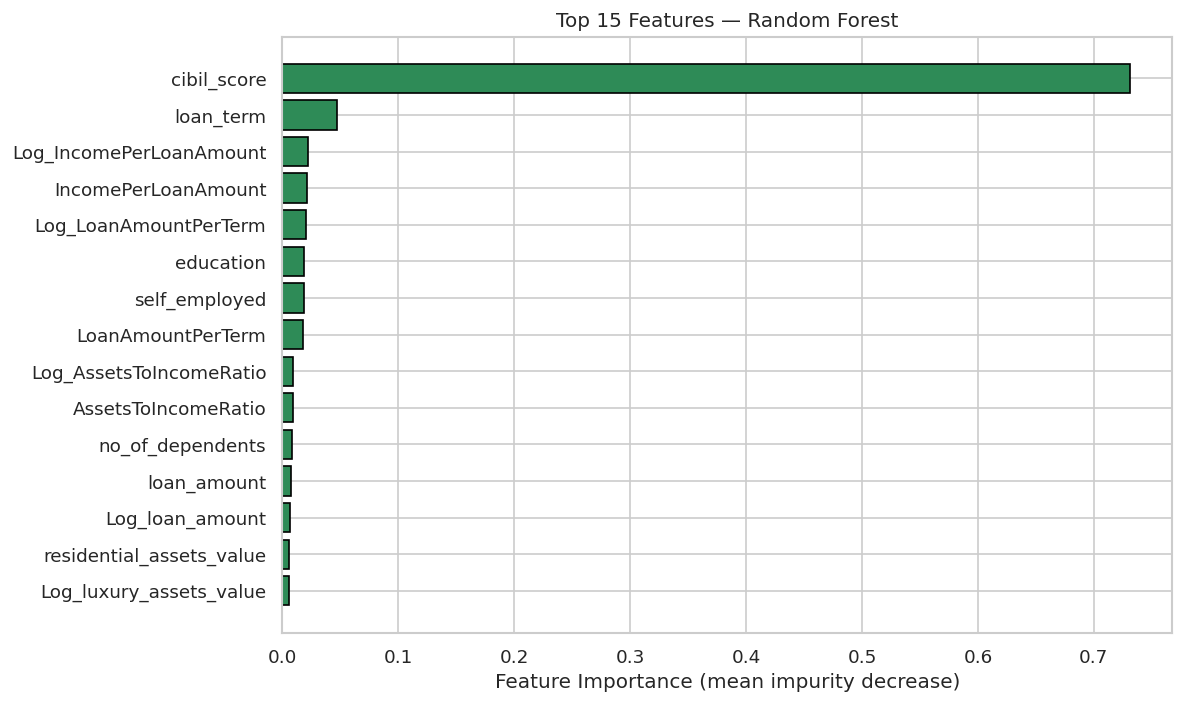

✅ Saved → Google Drive: rf_feature_importance.png


In [24]:
# Feature importance
fi_df = pd.DataFrame({
    'Feature':   FEATURE_NAMES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
         color='seagreen', edgecolor='black')
plt.xlabel("Feature Importance (mean impurity decrease)")
plt.title("Top 15 Features — Random Forest", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rf_feature_importance.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: rf_feature_importance.png")

XGBoost with  Time-Aware Stratified CV

In [25]:
# Compute scale_pos_weight = negative_samples / positive_samples
# This tells XGBoost how much extra weight to give the minority class
neg = (y_train_sm == 0).sum()
pos = (y_train_sm == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.3f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

# Stratified K-Fold CV
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1   = cross_val_score(xgb_model, X_train_sm, y_train_sm,
                           cv=skf, scoring='f1', n_jobs=-1)
cv_auc  = cross_val_score(xgb_model, X_train_sm, y_train_sm,
                           cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"\nStratified 5-Fold CV:")
print(f"   F1  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"   AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

xgb_model.fit(X_train_sm, y_train_sm)
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost test results:")
full_evaluate("XGBoost + SMOTE", y_test, xgb_pred, xgb_proba)
print()
print("Classification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['Rejected (N)', 'Approved (Y)']))

scale_pos_weight = 1.000

Stratified 5-Fold CV:
   F1  : 0.9974 ± 0.0012
   AUC : 0.9994 ± 0.0010

XGBoost test results:
  Model                         : Acc=0.9965  Prec=0.9962  Rec=0.9981  F1=0.9972  AUC=1.0000

Classification Report:
              precision    recall  f1-score   support

Rejected (N)       1.00      0.99      1.00       323
Approved (Y)       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



Confusion Matrices

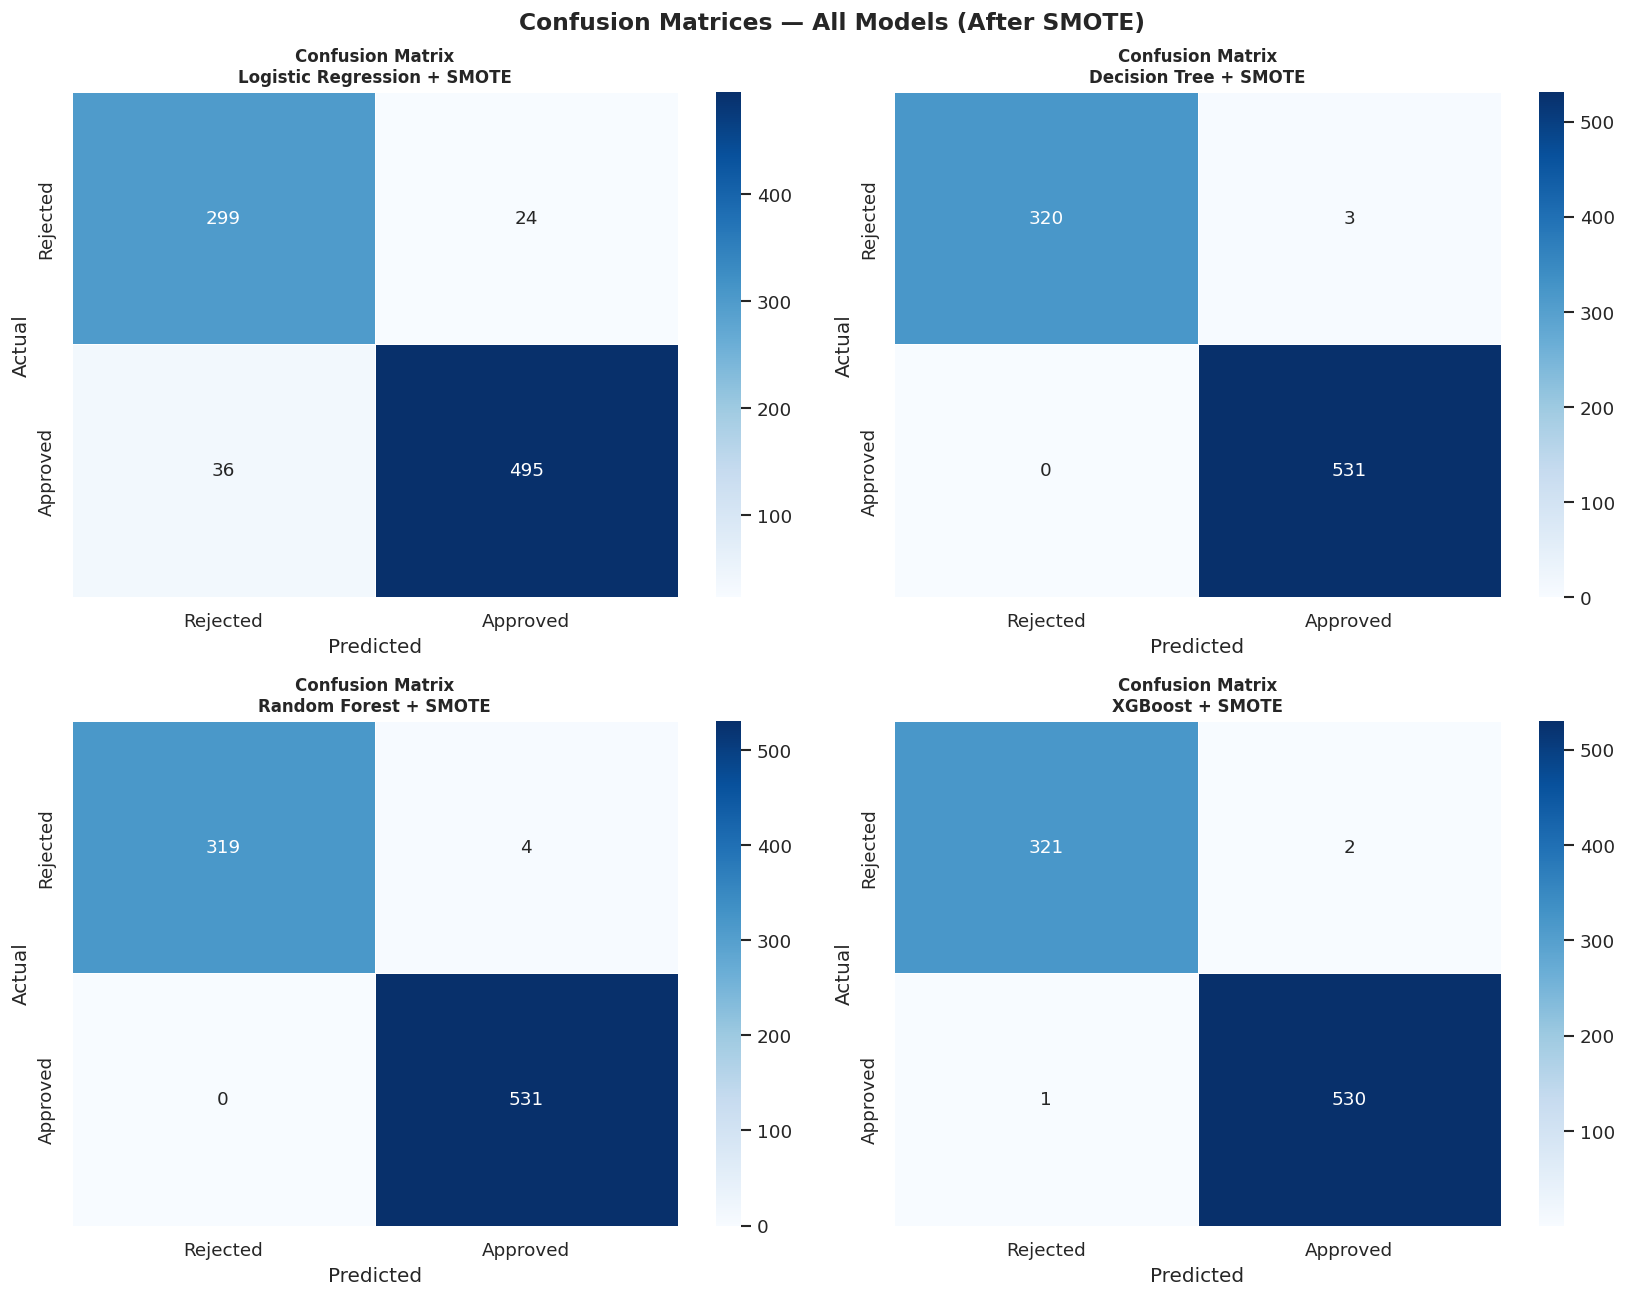

✅ Saved → Google Drive: confusion_after_smote.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Confusion Matrices — All Models (After SMOTE)", fontsize=14, fontweight='bold')

models_cm = [
    ("Logistic Regression + SMOTE", lr_sm_pred),
    ("Decision Tree + SMOTE",       dt_sm_pred),
    ("Random Forest + SMOTE",       rf_pred),
    ("XGBoost + SMOTE",             xgb_pred),
]
for ax, (name, preds) in zip(axes.flatten(), models_cm):
    plot_confusion(name, y_test, preds, ax)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_after_smote.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: confusion_after_smote.png")

ROC Curves — All Models

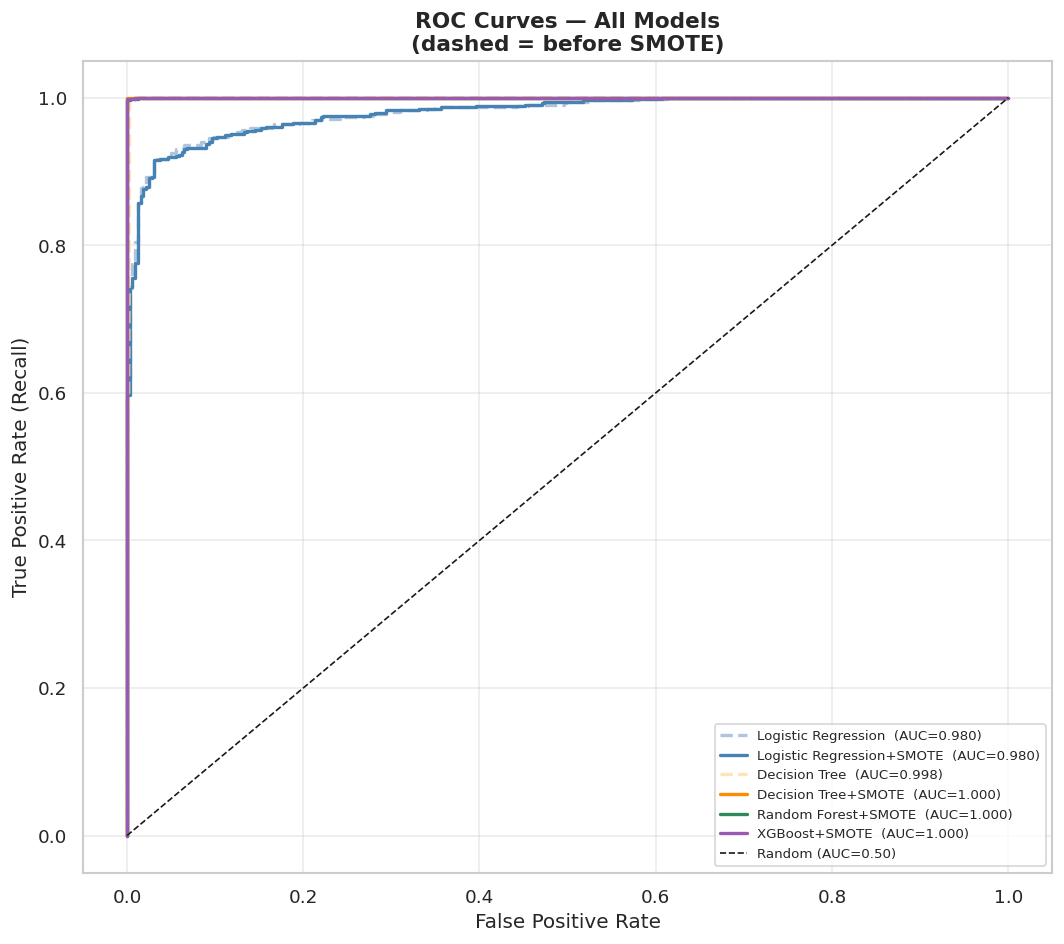

✅ Saved → Google Drive: roc_all_models.png


In [27]:
plt.figure(figsize=(9, 8))
roc_models = [
    ("Logistic Regression",       lr_proba,    'lightsteelblue', '--'),
    ("Logistic Regression+SMOTE", lr_sm_proba, 'steelblue',      '-'),
    ("Decision Tree",             dt_proba,    'moccasin',       '--'),
    ("Decision Tree+SMOTE",       dt_sm_proba, 'darkorange',     '-'),
    ("Random Forest+SMOTE",       rf_proba,    'seagreen',       '-'),
    ("XGBoost+SMOTE",             xgb_proba,   '#9B59B6',        '-'),
]
for name, proba, color, ls in roc_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc          = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, linestyle=ls,
             label=f"{name}  (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.50)')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curves — All Models\n(dashed = before SMOTE)", fontsize=13, fontweight='bold')
plt.legend(fontsize=8, loc='lower right'); plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/roc_all_models.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: roc_all_models.png")

Final Model Comparison

  FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Decision Tree,0.998829,0.99812,1.0,0.999059,0.998452
Decision Tree + SMOTE,0.996487,0.994382,1.0,0.997183,1.0
XGBoost + SMOTE,0.996487,0.996241,0.998117,0.997178,0.999983
Random Forest + SMOTE,0.995316,0.992523,1.0,0.996248,0.999971
Logistic Regression,0.933255,0.959302,0.932203,0.945559,0.979792
Logistic Regression + SMOTE,0.929742,0.953757,0.932203,0.942857,0.979558


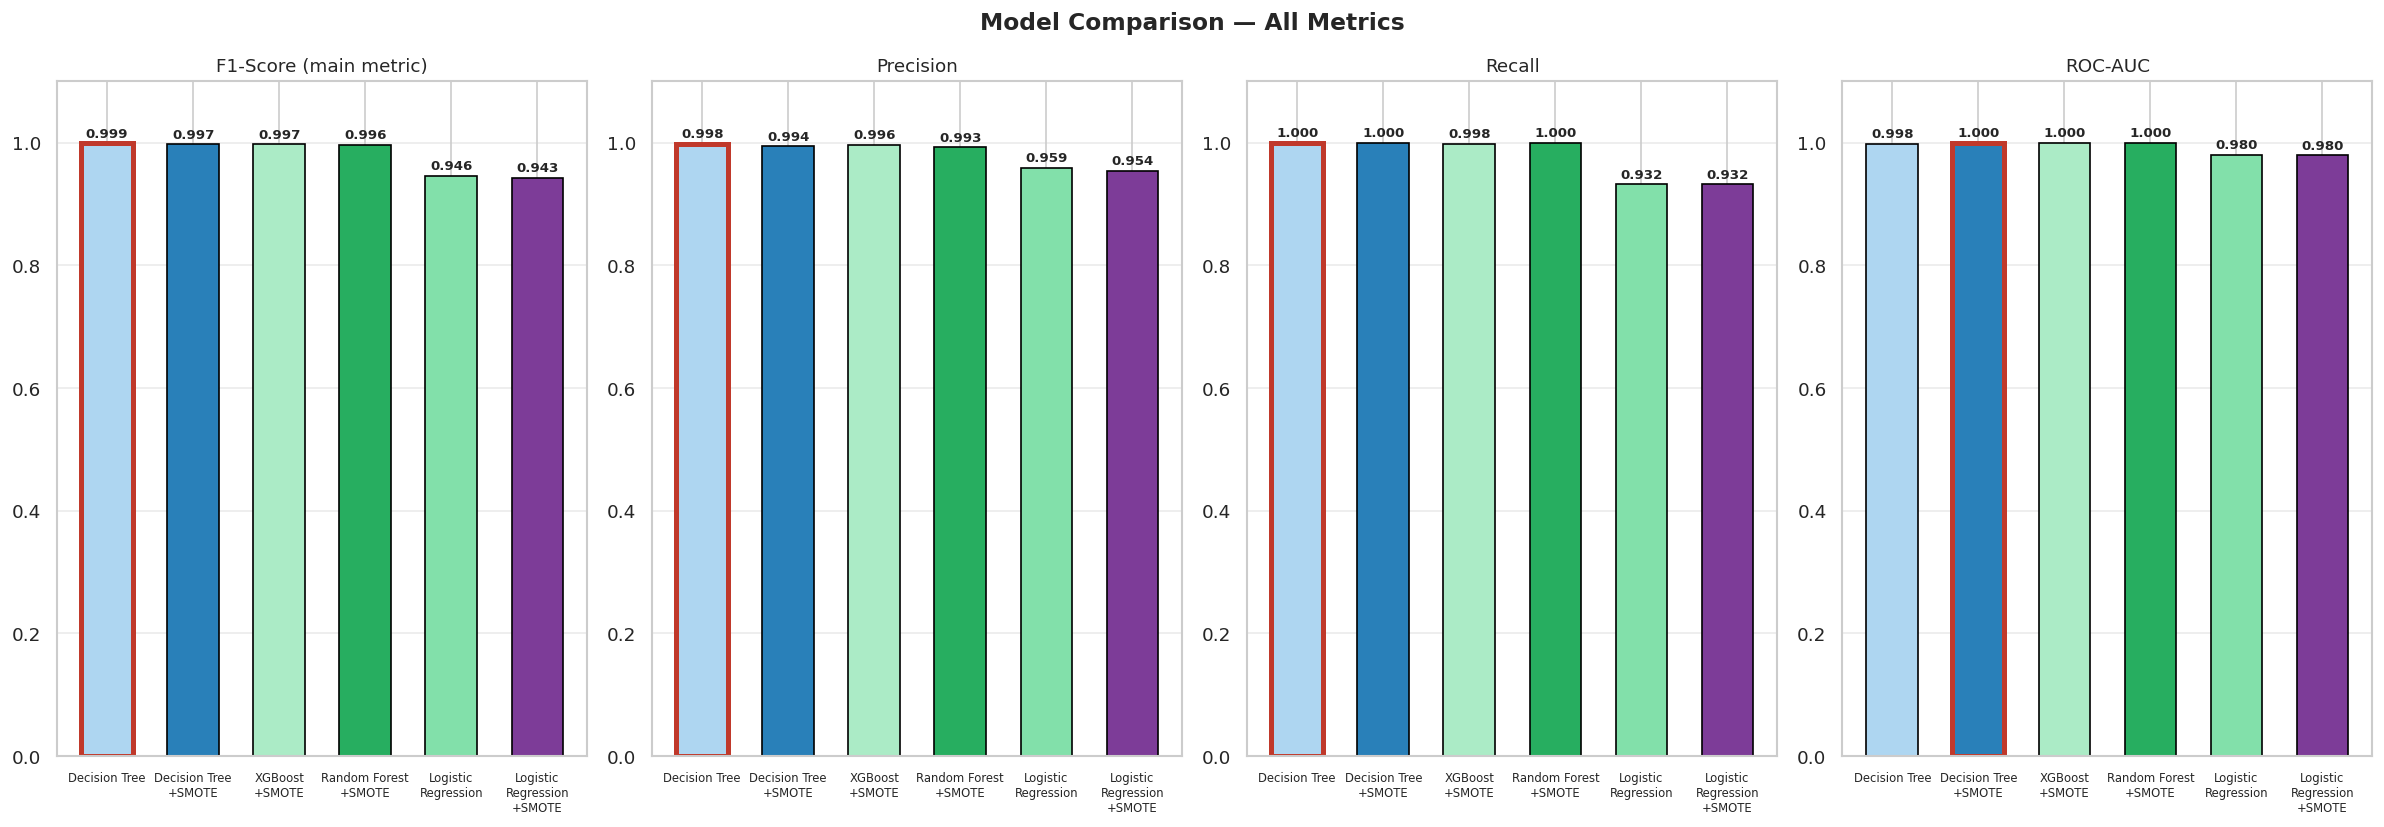

✅ Saved → Google Drive: final_model_comparison.png

🏆 Best model (by F1): Decision Tree
   F1-Score  : 0.9991
   Precision : 0.9981
   Recall    : 1.0000
   ROC-AUC   : 0.9985


In [28]:
comp_df = pd.DataFrame(RESULTS).T[['Accuracy','Precision','Recall','F1','AUC']].round(4)
comp_df.index.name = 'Model'
print("=" * 80)
print("  FINAL MODEL COMPARISON")
print("=" * 80)
display(comp_df.sort_values('F1', ascending=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 7))
fig.suptitle("Model Comparison — All Metrics", fontsize=14, fontweight='bold')

palette = ['#AED6F1','#2980B9','#ABEBC6','#27AE60','#82E0AA','#7D3C98']
metrics_show = [('F1','F1-Score (main metric)'),
                ('Precision','Precision'),
                ('Recall','Recall'),
                ('AUC','ROC-AUC')]

for ax, (metric, ylabel) in zip(axes, metrics_show):
    vals   = comp_df.sort_values('F1', ascending=False)[metric].values
    names  = comp_df.sort_values('F1', ascending=False).index.tolist()
    short  = [n.replace(' + SMOTE','\n+SMOTE').replace(' Regression','\nRegression') for n in names]
    bars   = ax.bar(range(len(names)), vals,
                    color=palette[:len(names)], edgecolor='black', width=0.6)
    best   = np.argmax(vals)
    bars[best].set_edgecolor('#C0392B'); bars[best].set_linewidth(3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{v:.3f}", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(ylabel, fontsize=11)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(short, fontsize=7)
    ax.set_ylim(0, 1.1); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/final_model_comparison.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: final_model_comparison.png")

winner = comp_df['F1'].idxmax()
print(f"\n🏆 Best model (by F1): {winner}")
print(f"   F1-Score  : {comp_df.loc[winner,'F1']:.4f}")
print(f"   Precision : {comp_df.loc[winner,'Precision']:.4f}")
print(f"   Recall    : {comp_df.loc[winner,'Recall']:.4f}")
print(f"   ROC-AUC   : {comp_df.loc[winner,'AUC']:.4f}")

Predicting a single loan Application.

In [29]:
def predict_loan(model, scaler, feature_names, applicant: dict, needs_scaling=False):
    """
    Predict loan approval probability for a new applicant.

    applicant = {
        'Gender': 'Male',  'Married': 'Yes',  'Dependents': '0',
        'Education': 'Graduate',  'Self_Employed': 'No',
        'ApplicantIncome': 5000,  'CoapplicantIncome': 2000,
        'LoanAmount': 150,  'Loan_Amount_Term': 360,
        'Credit_History': 1.0,  'Property_Area': 'Urban'
    }
    """
    # Build a one-row DataFrame and run through preprocessing
    row = pd.DataFrame([applicant])
    # Add dummy Loan_Status for preprocessing compatibility
    row['loan_status'] = 'Approved' # Use 'Approved' for dummy target
    X_new, _, _ = preprocess(row, is_train=True)

    # Align columns (in case one-hot creates different columns)
    if X_new.shape[1] != len(feature_names):
        print(f"⚠️  Feature count mismatch ({X_new.shape[1]} vs {len(feature_names)})")
        return None

    if needs_scaling:
        X_new = scaler.transform(X_new)

    proba  = model.predict_proba(X_new)[0, 1]
    pred   = "✅ APPROVED" if proba >= 0.5 else "❌ REJECTED"

    print(f"\n{'='*40}")
    print(f"  Loan Decision: {pred}")
    print(f"  Approval probability: {proba*100:.1f}%")
    print(f"{'='*40}")
    return proba

# ── Example applicant ─────────────────────────────────────────────────────────
# Corrected example_applicant dictionary to match the current dataset's features
example_applicant = {
    'no_of_dependents':           0,
    'education':                  'Graduate',
    'self_employed':              'No',
    'income_annum':               5849000,  # Example: 5.849 million
    'loan_amount':                12800000, # Example: 12.8 million
    'loan_term':                  360,      # Example: 360 months
    'cibil_score':                750,      # Example: Good CIBIL score
    'residential_assets_value':   1000000,  # Example assets
    'commercial_assets_value':    500000,
    'luxury_assets_value':        2000000,
    'bank_asset_value':           800000,
}

print("Applicant details:")
for k, v in example_applicant.items():
    print(f"   {k:<22}: {v}")

predict_loan(xgb_model, scaler, FEATURE_NAMES, example_applicant, needs_scaling=False)


Applicant details:
   no_of_dependents      : 0
   education             : Graduate
   self_employed         : No
   income_annum          : 5849000
   loan_amount           : 12800000
   loan_term             : 360
   cibil_score           : 750
   residential_assets_value: 1000000
   commercial_assets_value: 500000
   luxury_assets_value   : 2000000
   bank_asset_value      : 800000
   Label encoded 'education'
   Label encoded 'self_employed'

  Loan Decision: ✅ APPROVED
  Approval probability: 97.2%


np.float32(0.9716565)